# 265. Paint House II
https://leetcode.com/problems/paint-house-ii/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| Naive DP | O(n*k^2) | O(1) | For each house, try all k colors with min of prev |
| **Track min two (Optimal)** | **O(n*k)** | **O(1)** | Track first and second minimum from prev row |

## Methodology

For each house, we only need the minimum and second minimum cost from the previous row. If the current color matches the previous minimum's color, use the second minimum; otherwise use the minimum. This reduces the inner loop from O(k) to O(1) per color.

## Solutions

### C#

In [ ]:
public class Solution {
    public int MinCostII(int[][] costs) {
        int n = costs.Length;
        if (n == 0) return 0;
        int k = costs[0].Length;
        int min1 = 0, min2 = 0, minIdx = -1;
        for (int i = 0; i < n; i++) {
            int curMin1 = int.MaxValue, curMin2 = int.MaxValue, curIdx = -1;
            for (int j = 0; j < k; j++) {
                int cost = costs[i][j] + (j == minIdx ? min2 : min1);
                if (cost < curMin1) {
                    curMin2 = curMin1; curMin1 = cost; curIdx = j;
                } else if (cost < curMin2) {
                    curMin2 = cost;
                }
            }
            min1 = curMin1; min2 = curMin2; minIdx = curIdx;
        }
        return min1;
    }
}

### Python

In [ ]:
class Solution:
    def minCostII(self, costs: list[list[int]]) -> int:
        if not costs:
            return 0
        n, k = len(costs), len(costs[0])
        min1, min2, min_idx = 0, 0, -1
        for i in range(n):
            cur_min1, cur_min2, cur_idx = float('inf'), float('inf'), -1
            for j in range(k):
                cost = costs[i][j] + (min2 if j == min_idx else min1)
                if cost < cur_min1:
                    cur_min2, cur_min1, cur_idx = cur_min1, cost, j
                elif cost < cur_min2:
                    cur_min2 = cost
            min1, min2, min_idx = cur_min1, cur_min2, cur_idx
        return min1

### Go

In [ ]:
func minCostII(costs [][]int) int {
    n := len(costs)
    if n == 0 { return 0 }
    k := len(costs[0])
    min1, min2, minIdx := 0, 0, -1
    for i := 0; i < n; i++ {
        curMin1, curMin2, curIdx := math.MaxInt32, math.MaxInt32, -1
        for j := 0; j < k; j++ {
            cost := costs[i][j]
            if j == minIdx {
                cost += min2
            } else {
                cost += min1
            }
            if cost < curMin1 {
                curMin2, curMin1, curIdx = curMin1, cost, j
            } else if cost < curMin2 {
                curMin2 = cost
            }
        }
        min1, min2, minIdx = curMin1, curMin2, curIdx
    }
    return min1
}

### Rust

In [ ]:
impl Solution {
    pub fn min_cost_ii(costs: Vec<Vec<i32>>) -> i32 {
        if costs.is_empty() { return 0; }
        let (n, k) = (costs.len(), costs[0].len());
        let (mut min1, mut min2, mut min_idx) = (0i32, 0i32, usize::MAX);
        for i in 0..n {
            let (mut cm1, mut cm2, mut ci) = (i32::MAX, i32::MAX, 0);
            for j in 0..k {
                let cost = costs[i][j] + if j == min_idx { min2 } else { min1 };
                if cost < cm1 {
                    cm2 = cm1; cm1 = cost; ci = j;
                } else if cost < cm2 {
                    cm2 = cost;
                }
            }
            min1 = cm1; min2 = cm2; min_idx = ci;
        }
        min1
    }
}

## Example Scenarios

1. **Common Case**  
   **Input:** `costs = [[1,5,3],[2,9,4]]` ($n=2$, $k=3$)  
   House 0 picks color 0 (cost 1). House 1 cannot reuse color 0, so picks color 2 (cost 4). Total = $1 + 4 = 5$.

2. **Slightly Complex**  
   **Input:** `costs = [[8,2,5],[3,7,1],[6,4,9]]` ($n=3$, $k=3$)  
   Greedy fails here. House 0 picks color 1 (cost 2). House 1 picks color 2 (cost 1). House 2 picks color 1 (cost 4). Total = $2 + 1 + 4 = 7$.

3. **Edge Case: Time Factor**  
   **Input:** $n = 1000$ houses, $k = 1000$ colors, all costs equal to 1.  
   Every row is identical so first and second minimums are both 1. The algorithm processes $n \times k = 10^6$ entries in $O(nk)$ time.

4. **Edge Case: Space Factor**  
   **Input:** `costs = [[5]]` ($n=1$, $k=1$)  
   Single house and single color. No choice to make. Returns $5$. Uses $O(1)$ extra space.

5. **Almost-Impossible but Plausible**  
   **Input:** $n = 1000$ houses, $k = 2$, costs alternate `[1, 1000000]` and `[1000000, 1]`.  
   Adjacent houses are forced to opposite colors. Total = $1000 \times 1 = 1000$. Tracks only two minimums per row.

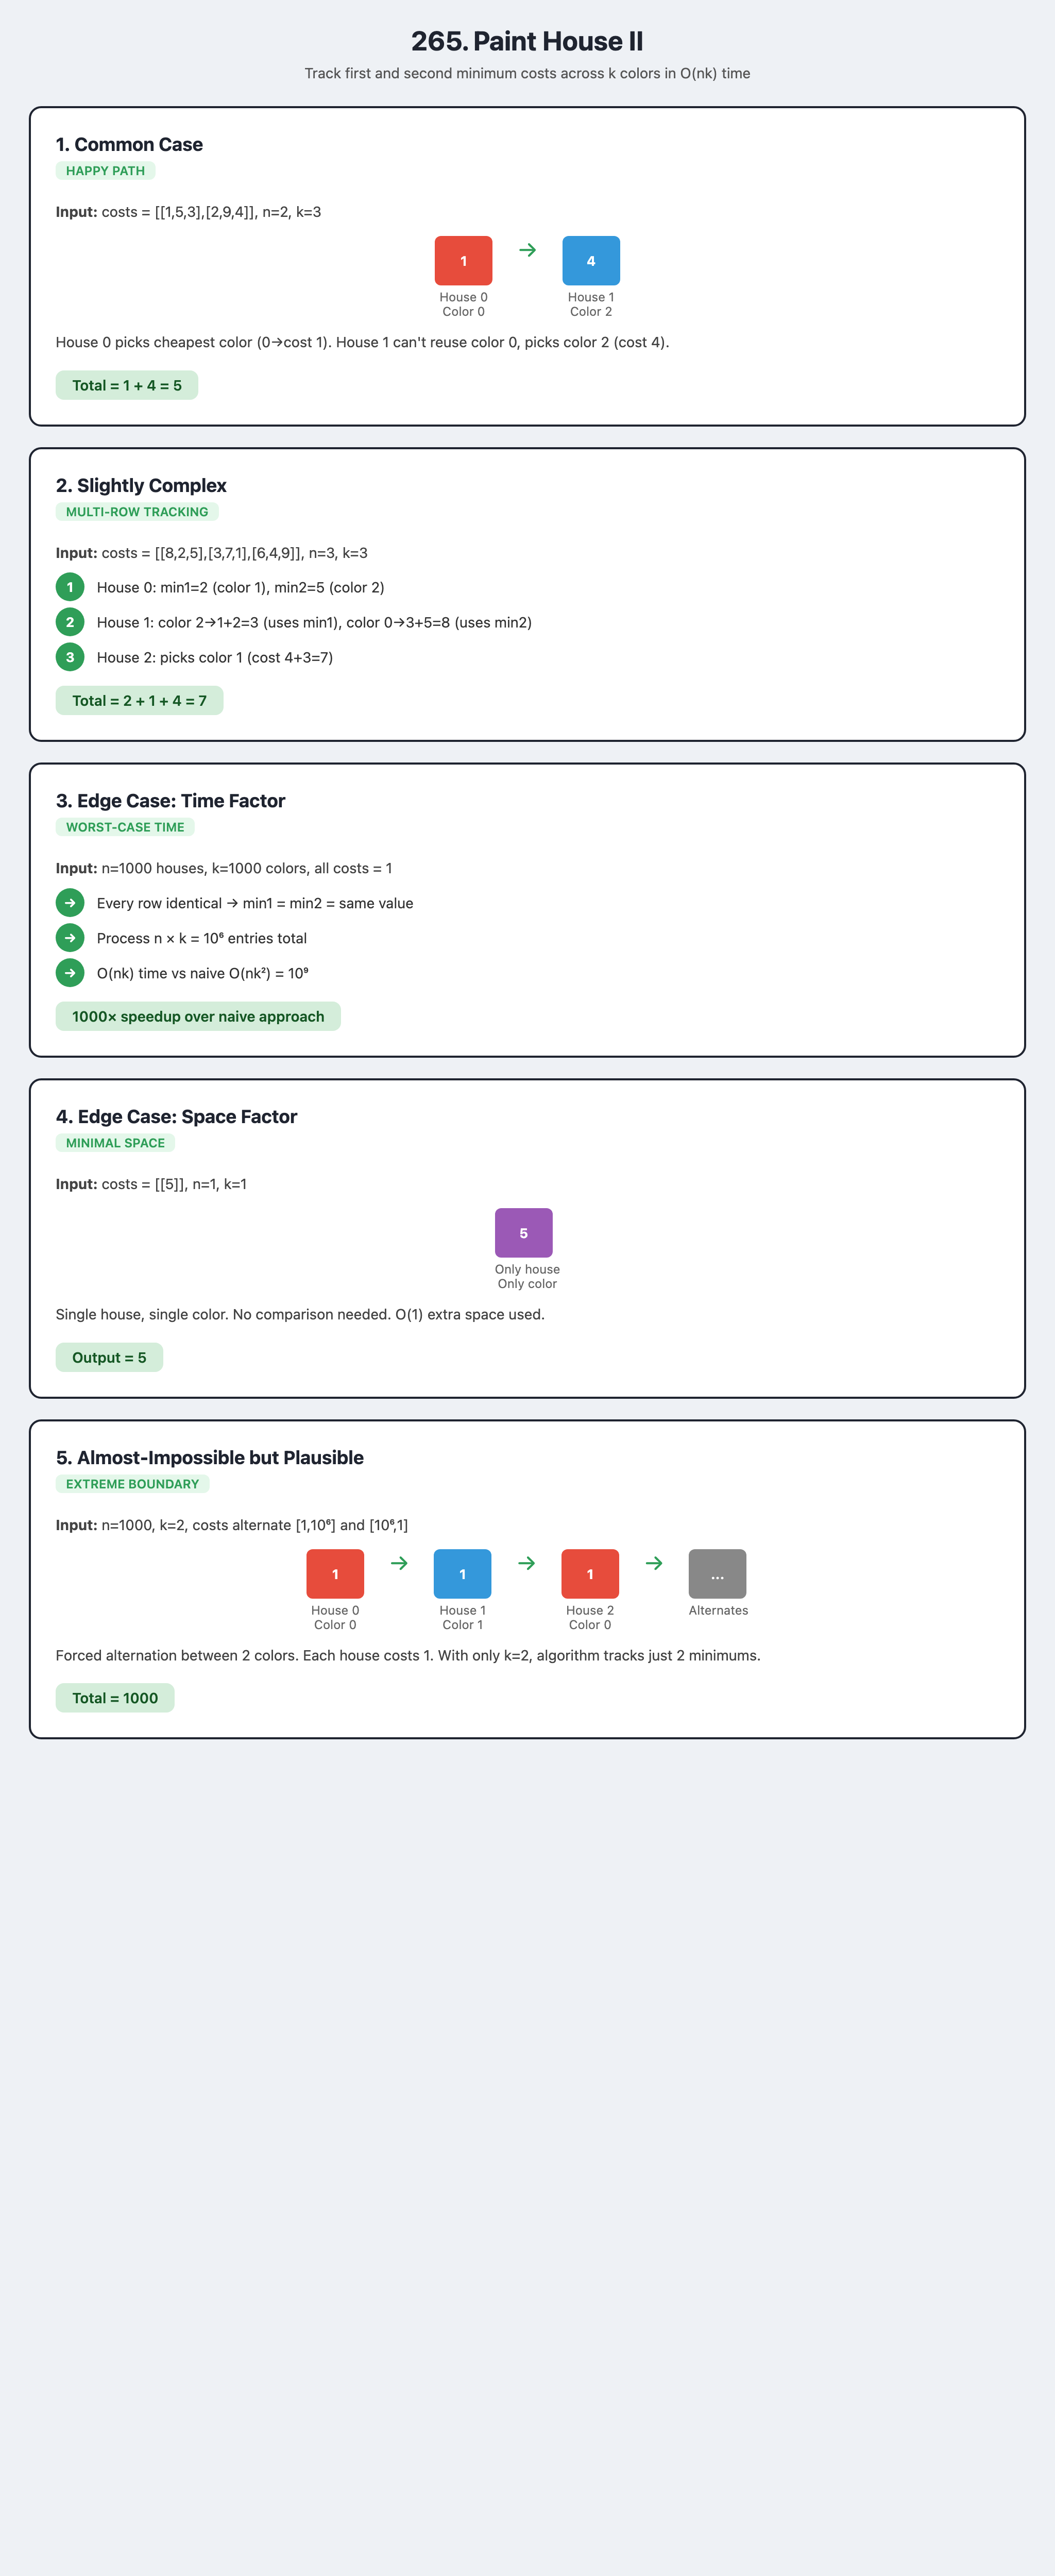